# **Named Entity Recognition**

Named Entity Recognition (NER) is an information extraction subtask that seeks to locate and classify named entities in unstructured text into pre-defined categories such as person names, organizations, locations, time expressions, quantities, monetary values, percentages, etc.

**our objectif** is to identify and categorize key information elements in a text.

we can use it in **Search engines**(Improve the relevance of results by identifying important entities in queries and documents) , also in **Sentiment analysis**( To understand opinions expressed about specific products, people, or organizations) , or in **Recommendation systems**(Personalize content recommendations based on entities mentioned in a user's history) , **Question-answering:** ....

In this notebook , we focuses on applying NER using an encoder model specifically trained for French, it's **PantagrueLLM**.

## **WikiNER dataset** :

In [1]:
from datasets import load_dataset

ds = load_dataset("mnaguib/WikiNER", "fr")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The WikiNER (fr) dataset is ideal for French NER due to its extensive coverage from Wikipedia, providing diverse entities and significant data volume. Its linguistic relevance to the French-trained PantagrueLLM model ensures optimal performance.

In [2]:
print(len(ds["train"]))
print(len(ds["test"]))

119038
13398


In [3]:
# one example
ds["train"][0]

{'id': 'fr-doc7913-sent16',
 'words': ['Delhi',
  'a',
  'quatre',
  'villes',
  'satellites',
  'principales',
  'qui',
  'se',
  'trouvent',
  'en',
  'dehors',
  'du',
  'territoire',
  'national',
  'de',
  'Delhi',
  '.'],
 'ner_tags': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]}

In [4]:
# to pandas
df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()

In [5]:
df_train.sample(2)

,id,words,ner_tags
118893,fr-doc10613-sent12,"[À, l', inverse, ,, Theo, de, Raadt, répondit,...","[0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, ..."
47118,fr-doc9419-sent46,"[Les, artistes, aussi, se, déplacent, sur, de,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## **Analyse of data**

Distribution of Word Counts (df_train):
count    119038.000000
mean         26.143366
std          13.685830
min           1.000000
25%          17.000000
50%          23.000000
75%          33.000000
max         242.000000
Name: count, dtype: float64


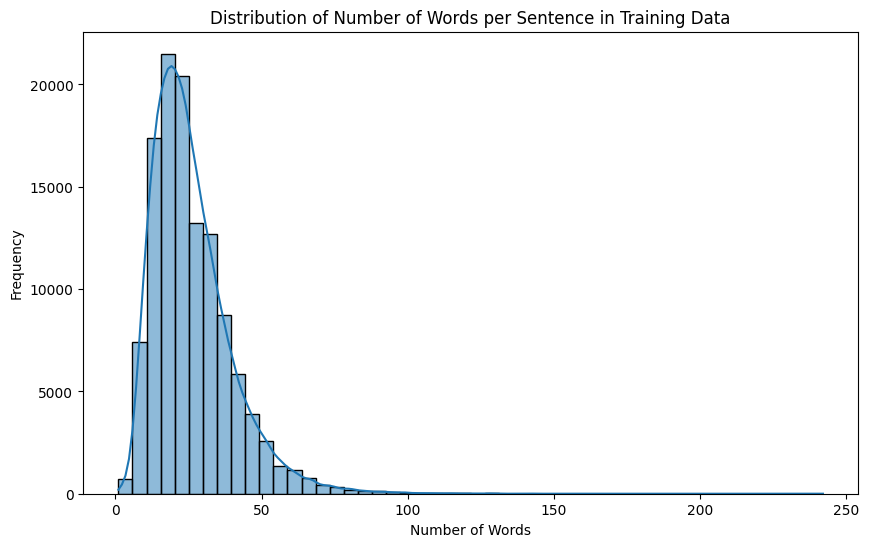

In [6]:
# Train dataset
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df_train['count'] = df_train['words'].apply(len)

print("Distribution of Word Counts (df_train):")
print(df_train['count'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_train['count'], bins=50, kde=True)
plt.title('Distribution of Number of Words per Sentence in Training Data')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

Distribution of Word Counts (df_test):
count    13398.000000
mean        26.331243
std         13.796530
min          1.000000
25%         17.000000
50%         24.000000
75%         33.000000
max        153.000000
Name: count, dtype: float64


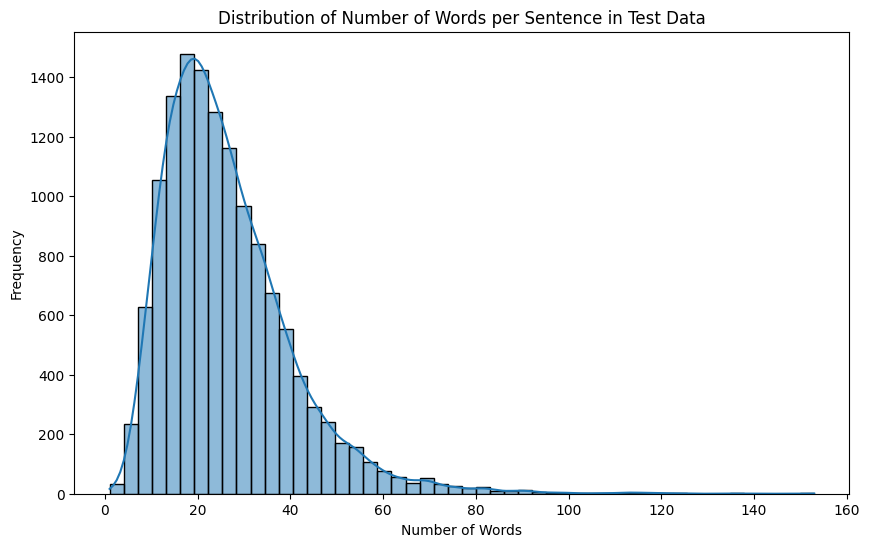

In [7]:
#Test dataset
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df_test['count'] = df_test['words'].apply(len)

print("Distribution of Word Counts (df_test):")
print(df_test['count'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_test['count'], bins=50, kde=True)
plt.title('Distribution of Number of Words per Sentence in Test Data')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [8]:
# We limit the number of sentences , by a filter
df_train = df_train[df_train['count'] < 50]
df_test = df_test[df_test['count'] <50]

In [9]:
# The new number of examples in train and test datasets
print(len(df_train))
print(len(df_test))

111803
12589


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import Dataset

train_ds = Dataset.from_pandas(df_train)   # len(df_train) = 111803
train_ds_sampled = train_ds.shuffle(seed=42).select(range(111000)) #111000

train_val = train_ds_sampled.train_test_split(test_size=0.1 ,seed=0)
df_train = train_val["train"].to_pandas()
df_val = train_val["test"].to_pandas()

test_hf_ds = Dataset.from_pandas(df_test)  #len(df_test) = 12589
test_ds_sampled = test_hf_ds.shuffle(seed=42).select(range(12500))
df_test = test_ds_sampled.to_pandas()

print(f"df_train_split shape: {df_train.shape}")
print(f"df_val_split shape: {df_val.shape}")
print(f"df_test_split shape: {df_test.shape}")

df_train_split shape: (99900, 5)
df_val_split shape: (11100, 5)
df_test_split shape: (12500, 5)


In [11]:
df_train.sample(4)

,id,words,ner_tags,count,__index_level_0__
11848,fr-doc9772-sent63,"[Cette, dernière, exigence, ,, que, Verdi, lui...","[0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",27,42066
37658,fr-doc862-sent2,"[Saint-Georges-de-Rouelley, est, distante, de,...","[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",14,115571
51879,fr-doc3381-sent5,"[Depuis, la, création, de, la, communauté, d',...","[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",26,13410
47591,fr-doc5301-sent22,"[En, 1566, ,, le, roi, s', arrêta, enfin, à, M...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",17,65098


In [12]:
df_test.sample(4)

,id,words,ner_tags,count,__index_level_0__
9,fr-doc11550-sent0,"[Les, jours, juliens, tronqués, sont, utilisés...","[0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, ...",28,13315
4328,fr-doc11508-sent6,"[Il, prend, l', initiative, de, plusieurs, opé...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, ...",28,11951
2477,fr-doc11623-sent1,"[Très, vite, ,, elle, obtient, des, rôles, sec...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",38,195
8609,fr-doc11210-sent19,"[Du, Thielbek, ,, sur, 2800, déportés, seuleme...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",11,5486


In [13]:
df_val.sample(4)

,id,words,ner_tags,count,__index_level_0__
8246,fr-doc3089-sent12,"[Ce, dernier, ayant, fait, appel, mais, Yves, ...","[0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, ...",36,44070
11029,fr-doc2378-sent8,"[Cette, province, compte, 9, communes, germano...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...",27,61332
1696,fr-doc10777-sent29,"[Ses, fils, allèrent, l', enterrer, à, Soisson...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",26,30850
6743,fr-doc7438-sent0,"[Il, est, le, fils, de, Philippe, de, Gaulle, ...","[0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 2, 2, 2, 0, 0, ...",22,69592


In [14]:
df_train.info()   #all values are non_null (ok)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99900 entries, 0 to 99899
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 99900 non-null  object
 1   words              99900 non-null  object
 2   ner_tags           99900 non-null  object
 3   count              99900 non-null  int64 
 4   __index_level_0__  99900 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 3.8+ MB


In [15]:
df_train.describe()  #more informations about trai_data

,count,__index_level_0__
count,99900.000000,99900.000000
mean,23.851962,59544.861812
std,10.069709,34358.821525
min,1.000000,0.000000
25%,16.000000,29817.750000
50%,23.000000,59584.000000
75%,31.000000,89270.250000
max,49.000000,119036.000000


## **Converting Word Lists to Sentences**

In [16]:
df_train['sentence'] = df_train['words'].str.join(" ")
df_test['sentence'] = df_test['words'].str.join(" ")
df_val['sentence'] = df_val['words'].str.join(" ")

print(df_train['sentence'][0])
print()
print(df_test['sentence'][0])
print()
print(df_val['sentence'][0])

En effet les travaux ont repris grâce à la pression américaine qui a aussi contribué à la révolte du Panamá envers cette même Colombie .

L' École supérieure d' économie de Prague , quant à elle , peut se targuer d' avoir vu passer sur ses bancs Václav Klaus , ancien ministre de l' économie , premier ministre puis président du pays , Jiří Paroubek et Miloš Zeman , ancien premier ministres socialistes .

A partir de 1949 , la victoire de Mao Zedong en Chine permet au Viêt-Minh de recevoir un équipement important venu de Chine , de l' Union soviétique et des autres pays du bloc communiste .


In [17]:
# we take one example from df_val (all others are the same)
df_val.head()  # we add a new colomne named "sentence"(ok)

,id,words,ner_tags,count,__index_level_0__,sentence
0,fr-doc9899-sent118,"[A, partir, de, 1949, ,, la, victoire, de, Mao...","[0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 1, 0, 0, 4, ...",36,112940,"A partir de 1949 , la victoire de Mao Zedong e..."
1,fr-doc10852-sent34,"[La, Suisse, est, habituellement, divisée, en,...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",11,63739,La Suisse est habituellement divisée en trois ...
2,fr-doc10778-sent20,"[En, 1977-1978, ,, ce, fut, Spassky, qui, remp...","[0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",32,76880,"En 1977-1978 , ce fut Spassky qui remplaça Fis..."
3,fr-doc8420-sent1,"[Il, est, nommé, en, l', honneur, de, l', astr...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0]",12,13656,Il est nommé en l' honneur de l' astronome Edw...
4,fr-doc9810-sent3,"[Aux, axiomes, de, la, logique, propositionnel...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",24,41565,Aux axiomes de la logique propositionnelle s' ...


# **PantagruelLLM , RoBERTa , CamemBERT models for text**

In [20]:
import sys
# Force uninstall sympy to clear potential conflicts
#!pip uninstall -y sympy

# Force reinstall torch with the correct versions to ensure compatible sympy is pulled
# Using versions from previous successful install output: torch-2.3.0+cu121 torchaudio-2.3.0+cu121 torchvision-0.18.0+cu121
#!pip install --force-reinstall torch==2.3.0+cu121 torchvision==0.18.0+cu121 torchaudio==2.3.0+cu121 --index-url https://download.pytorch.org/whl/cu121


Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 18.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 89.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 30.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 59.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 108.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 814.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 779.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━

In [18]:
import torch
from transformers import AutoTokenizer, AutoModel

# Load the tokenizer and model
model_name = "camambert_base"
#model_name = "FacebookAI/roberta-base"
#model_name = "PantagrueLLM/text-base-wiki"
#model_name = "PantagrueLLM/text-base-camtok-wiki"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## **Named Entity Recognition (NER) standard**

We use the standard Named Entity Recognition (NER) tags, commonly used in dataset WikiNER.
* 'O' means Outside of an entity.
* 'LOC' means location (cities, countries, rivers, mountains...).
* 'PER' means person( people's first names, last names, or full name...).
* 'MISC' means Miscellaneous (nationalities, religions, political groups, events, artifacts, and abstract concepts).

**In this data , there is no MISC entity !**
* 'ORG' means organisation (companies, agencies, institutions, and groups).

In [19]:
label_list = ['O', 'LOC', 'PER', 'ORG']
print(f"label list: {label_list}")
num_labels = len(label_list)
print(f"Number of labels: {num_labels}")

label list: ['O', 'LOC', 'PER', 'ORG']
Number of labels: 4


In [ ]:
!pip install torch==2.3.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install torchtext==0.18.0

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 37.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 60.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 114.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 906.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 16.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.3 MB/s eta 0:00:00


In [20]:
# function to tokenize and align labels
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["words"],
        is_split_into_words=True,
        truncation=True
    )

    all_labels = []
    for i, ner_tags_original in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        label_ids = []
        previous_word_idx = None

        for word_idx in word_ids:
            if word_idx is None:
                # [CLS], [SEP] ou padding -> -100
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                # C'est le début d'un nouveau mot -> on prend le vrai tag
                label_ids.append(ner_tags_original[word_idx])
            else:
                # C'est un morceau de mot (ex: ##ïdo) -> -100
                label_ids.append(-100)
            previous_word_idx = word_idx

        all_labels.append(label_ids)

    tokenized_inputs["labels"] = all_labels
    return tokenized_inputs

In [21]:
import numpy as np
# function to delete the MISC entity , and simplify the data
def map_ner_tags_to_simplified(examples):
    new_ner_tags = []
    for ner_tag_sequence in examples["ner_tags"]:
        cleaned_sequence = []
        for label_id in ner_tag_sequence:
            if label_id == 4:
                cleaned_sequence.append(3) # Remap 4 to 3 (ORG)
            elif label_id > 3: # If any other unexpected high labels, default to O
                cleaned_sequence.append(0)
            else:
                cleaned_sequence.append(label_id) # Keep 0, 1, 2, 3 as they are
        new_ner_tags.append(cleaned_sequence)
    return {"ner_tags": new_ner_tags}

In [22]:
#the data colator for :label alignment  and adding attention mask ,
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

In [23]:
# We Apply the remapping function before tokenization and alignment
train_dataset = Dataset.from_pandas(df_train).map(map_ner_tags_to_simplified, batched=True)
val_dataset = Dataset.from_pandas(df_val).map(map_ner_tags_to_simplified, batched=True)

# Now, we apply the tokenization and alignment
train_dataset = train_dataset.map(tokenize_and_align_labels, batched=True)
val_dataset = val_dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/99900 [00:00<?, ? examples/s]

Map:   0%|          | 0/11100 [00:00<?, ? examples/s]

Map:   0%|          | 0/99900 [00:00<?, ? examples/s]

Map:   0%|          | 0/11100 [00:00<?, ? examples/s]

In [25]:
!pip install evaluate
!pip install seqeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 13.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.2.0
    Uninstalling fsspec-2026.2.0:
      Successfully uninstalled fsspec-2026.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=27e72e037a16c087db7b6313be3a53e1501465aff733b00dd2c7e06196c64af6
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [26]:
import numpy as np
import evaluate

metric = evaluate.load("seqeval")    # We load the metric

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # On supprime les indices ignorés (-100)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [27]:
from collections import Counter
import torch

# On récupère les labels directement depuis le dataset transformé
all_labels_train = [label for sublist in train_dataset["ner_tags"] for label in sublist]
tag_counts = Counter(all_labels_train)

# Calcul des poids sur les 4 labels (0, 1, 2, 3)
num_expected_labels = 4
counts_for_weights = [tag_counts.get(i, 0) for i in range(num_expected_labels)]

# Calculate inverse frequencies for weighting
total_count = sum(counts_for_weights)
class_weights_raw = []
for count in counts_for_weights:
    if count == 0:
        class_weights_raw.append(0.0) # Assign 0 weight for completely absent classes
    else:
        # Inverse frequency weighting: higher weight for less frequent classes
        class_weights_raw.append(total_count / count)

# Normalize non-zero weights (optional but good practice)
non_zero_weights_sum = sum(w for w in class_weights_raw if w > 0)
normalized_class_weights = []
if non_zero_weights_sum > 0: # Avoid division by zero if all counts are zero (unlikely)
    effective_num_active_labels = sum(1 for w in class_weights_raw if w > 0)
    for w in class_weights_raw:
        if w == 0.0:
            normalized_class_weights.append(0.0)
        else:
            normalized_class_weights.append(w / non_zero_weights_sum * effective_num_active_labels)
else:
    normalized_class_weights = class_weights_raw     # All zeros if no active classes

# Convert to a torch tensor
loss_weights = torch.tensor(normalized_class_weights, dtype=torch.float)
print(f"Calculated loss weights: {loss_weights}")

Calculated loss weights: tensor([0.0361, 0.6918, 0.8592, 2.4129])


# **The Model : Encoder + MLP**

In [28]:
import torch.nn as nn

class MLP(nn.Module):
  def __init__(self, input_dim, output_dim):
    super(MLP, self).__init__()
    self.classifier_head = nn.Sequential(
       nn.Linear(input_dim, 1024),
       nn.ReLU(),
       nn.Dropout(0.2),
       nn.Linear(1024, 512),
       nn.ReLU(),
       nn.Dropout(0.1),
       nn.Linear(512, output_dim)    # Output directly num_labels logits = 4
    )

  def forward(self, x):
    return self.classifier_head(x)

In [31]:
import torch.nn as nn
from transformers import AutoModel, AutoConfig # Import AutoConfig

class PantagruelNER(nn.Module):
    def __init__(self, model_name, num_labels):
        super(PantagruelNER, self).__init__()
        # We Load config
        config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
        # Removed: if not hasattr(config, "model_type") or config.model_type != "text": config.model_type = "text"

        self.encoder = AutoModel.from_pretrained(model_name, config=config, trust_remote_code=True)
        print(self.encoder)

        # On gèle tout l'encodeur par défaut
        for param in self.encoder.parameters():
            param.requires_grad = False

        # On dégel les deux derniers blocs (10 et 11)
        # self.encoder.blocks contient la ModuleList de 12 blocs
        for i in range(10, 12):
          # for roberta model
          for param in self.encoder.encoder.layer[i].parameters():
            param.requires_grad = True

          # for pantgruel model
          #for param in self.encoder.blocks[i].parameters():
            #param.requires_grad = True

        self.classifier = MLP(self.encoder.config.hidden_size, num_labels)
        self.num_labels = num_labels    # We store num_labels for loss calculation

    def forward(self, input_ids, attention_mask=None, labels=None):
        # encoder (PantagruelLLM)
        # Explicitly pass mode='text' for text inputs
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs[0]    # We take the last hidden state

        # classifier(MLP)
        logits = self.classifier(sequence_output)

        loss = None
        if labels is not None:
            # Pass the calculated loss_weights to CrossEntropyLoss
            loss_fct = nn.CrossEntropyLoss(weight=loss_weights.to(logits.device), ignore_index=-100)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

model = PantagruelNER(model_name, num_labels=4)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

# **Training the Model**

In [ ]:
from transformers import TrainingArguments, Trainer
import os

# CUDA_LAUNCH_BLOCKING for detailed error messages
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Define training arguments
training_args = TrainingArguments(
    output_dir="./ner_RoBERTa_results",  # Output directory
    eval_strategy="epoch",                # Evaluation strategy
    learning_rate=1e-4,                    # Learning rate
    per_device_train_batch_size=16,        # Reduced batch size
    per_device_eval_batch_size=16,        # Reduced batch size for evaluation
    num_train_epochs=10,                    # Number of training epochs
    weight_decay=0.04,                     # Strength of weight decay
    logging_dir='./ner_RoBERTa_logs',   # Directory for storing logs
    logging_steps=500,
    save_strategy="epoch",                 # Save checkpoint every epoch
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",     # Metric to use to compare models
    greater_is_better=True                # Greater f&-scoreis better
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics

)

# Train the model
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.217313,0.287783,0.610851,0.751813,0.674041,0.947068
2,0.240010,0.240885,0.596086,0.733035,0.657505,0.946622
3,0.216418,0.230518,0.648282,0.773710,0.705464,0.953716
4,0.179012,0.250516,0.662430,0.794997,0.722684,0.958272
5,0.159837,0.225497,0.697024,0.823944,0.755188,0.963600
6,0.136956,0.235277,0.694002,0.818114,0.750965,0.962589
7,0.112227,0.248329,0.714504,0.825571,0.766032,0.965938
8,0.093523,0.266283,0.764674,0.866382,0.812357,0.973695


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: Use

### **Evaluation Metrics Evolution**

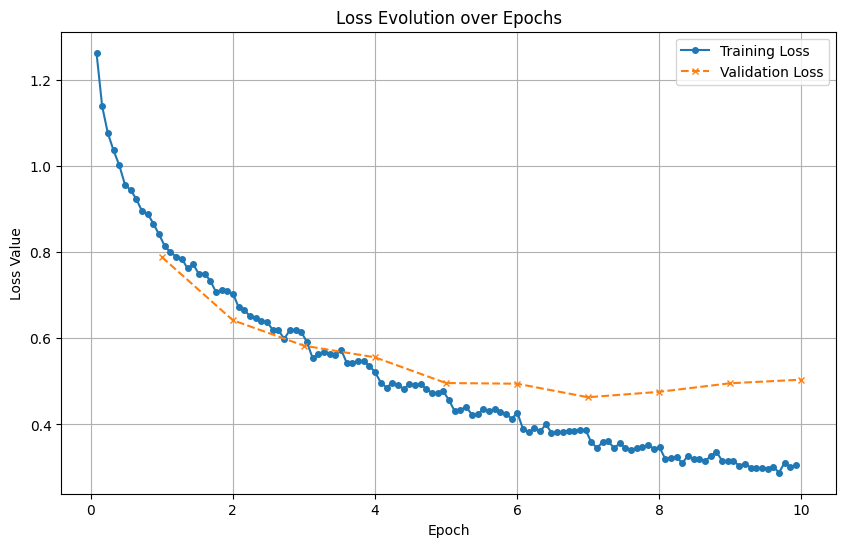

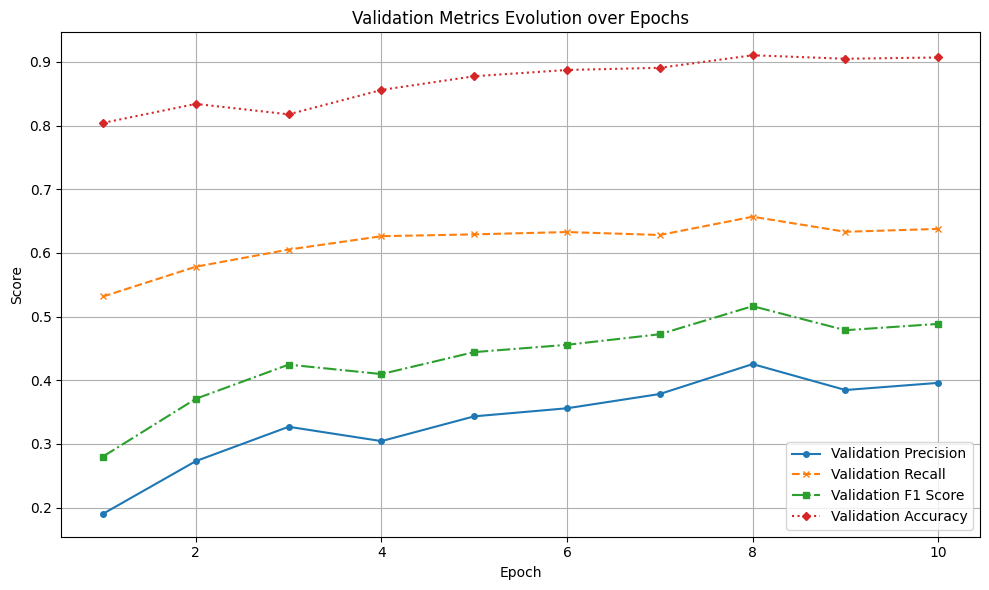

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract training and evaluation logs
log_history = trainer.state.log_history

train_logs = [entry for entry in log_history if 'loss' in entry and 'learning_rate' in entry]
eval_logs = [entry for entry in log_history if 'eval_loss' in entry]

# Prepare data for plotting
train_epochs = [log['epoch'] for log in train_logs]
train_losses = [log['loss'] for log in train_logs]

eval_epochs = [log['epoch'] for log in eval_logs]
eval_losses = [log['eval_loss'] for log in eval_logs]
eval_precision = [log['eval_precision'] for log in eval_logs]
eval_recall = [log['eval_recall'] for log in eval_logs]
eval_f1 = [log['eval_f1'] for log in eval_logs]
eval_accuracy = [log['eval_accuracy'] for log in eval_logs]

# Plotting function for Loss
def plot_loss_metrics(train_data, eval_data, metric_name, ylabel):
    plt.figure(figsize=(10, 6))
    plt.plot(train_epochs, train_data, label=f'Training {metric_name}', marker='o', linestyle='-', markersize=4)
    plt.plot(eval_epochs, eval_data, label=f'Validation {metric_name}', marker='x', linestyle='--', markersize=4)
    plt.title(f'{metric_name} Evolution over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot Loss
plot_loss_metrics(train_losses, eval_losses, 'Loss', 'Loss Value')

# Generate filename from model_name
model_name_for_file = model_name.replace('/', '_')

# Plot all Validation Metrics on a single graph
plt.figure(figsize=(10, 6))
plt.plot(eval_epochs, eval_precision, label='Validation Precision', marker='o', linestyle='-', markersize=4)
plt.plot(eval_epochs, eval_recall, label='Validation Recall', marker='x', linestyle='--', markersize=4)
plt.plot(eval_epochs, eval_f1, label='Validation F1 Score', marker='s', linestyle='-.', markersize=4)
plt.plot(eval_epochs, eval_accuracy, label='Validation Accuracy', marker='D', linestyle=':', markersize=4)
plt.title('Validation Metrics Evolution over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'metrics_{model_name_for_file}.png') # Save the plot
plt.show()

### **Final Test Data Metrics**

In [ ]:
from datasets import Dataset

test_dataset = Dataset.from_pandas(df_test).map(map_ner_tags_to_simplified, batched=True)
test_dataset = test_dataset.map(tokenize_and_align_labels, batched=True)

final_metrics = trainer.evaluate(test_dataset)


print(f"Final Résults for this model : {final_metrics}")

Map:   0%|          | 0/12500 [00:00<?, ? examples/s]

Map:   0%|          | 0/12500 [00:00<?, ? examples/s]

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#!cd ner_pantagruel_results && ls
!ls -F

Please replace the content of your `app5.py` file with the following corrected code to fix the entity extraction:


In [ ]:
%%writefile app5.py
import streamlit as st
import torch
import torch.nn as nn
import os
from transformers import AutoModel, AutoConfig, AutoTokenizer
from safetensors.torch import load_file

# --- CONFIGURATION ---
st.set_page_config(page_title="PICTO LIG - Pantagruel NER", layout="wide")

# Paramètres exacts du notebook
MODEL_NAME = "PantagrueLLM/text-base-camtok-wiki"
PATH_LOCAL_WEIGHTS = "./PantagrueLLM_text-base-camtok-wiki/model.safetensors"
LABEL_LIST = ['O', 'LOC', 'PER', 'ORG'] # Ordre du notebook

# --- ARCHITECTURE (COPIE DU NOTEBOOK) ---
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.classifier_head = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, output_dim)
        )
    def forward(self, x): return self.classifier_head(x)

class PantagruelNER(nn.Module):
    def __init__(self, model_name, num_labels):
        super(PantagruelNER, self).__init__()
        config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
        config.model_type = "text"
        self.encoder = AutoModel.from_pretrained(model_name, config=config, trust_remote_code=True)
        self.classifier = MLP(self.encoder.config.hidden_size, num_labels)
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask=None):
        sequence_output = self.encoder(input_ids=input_ids, attention_mask=attention_mask)[0]
        return self.classifier(sequence_output)

# --- CHARGEMENT ---
@st.cache_resource
def load_resources():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    model = PantagruelNER(MODEL_NAME, len(LABEL_LIST))

    if os.path.exists(PATH_LOCAL_WEIGHTS):
        model.load_state_dict(load_file(PATH_LOCAL_WEIGHTS), strict=True)
        model.to(device).eval()
        return model, tokenizer, device
    st.error(f"Model weights not found at {PATH_LOCAL_WEIGHTS}. Please ensure the model is trained and saved.")
    return None, None, None

model, tokenizer, device = load_resources()

# --- INTERFACE ---
st.title("🛡️ Pantagruel NER - LIG")
text_input = st.text_area("Texte :", "Emmanuel Macron est à Paris au siège du LIG.")

if st.button("Extraire les entités") and model:
    inputs = tokenizer(text_input, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        logits = model(inputs["input_ids"], inputs["attention_mask"])

    predictions = torch.argmax(logits, dim=2).squeeze().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"].squeeze().cpu().numpy())

    # CORRECTED Logic for token-to-word and entity reconstruction
    res_entities = []
    curr_word_buffer = [] # To accumulate tokens that form a word
    curr_word_tag = "O"

    for token, pred_id in zip(tokens, predictions):
        if token in ["<s>", "</s>", "<pad>"]: # Ignore special tokens
            continue

        tag_for_token = LABEL_LIST[pred_id]

        # Check if this token starts a new word using the SentencePiece prefix (U+2581)
        if token.startswith(" ") or token.startswith(" "): # Added U+2581 check
            # If we have a word accumulated, add it to res_entities
            if curr_word_buffer:
                res_entities.append(("".join(curr_word_buffer), curr_word_tag))

            # Start a new word
            curr_word_buffer = [token.lstrip(" ").lstrip(" ")] # Remove the U+2581 prefix or standard space
            curr_word_tag = tag_for_token # The tag of the first subword token sets the word tag initially
        else: # Continuation of the current word (subword) or punctuation without a leading space
            curr_word_buffer.append(token)
            # If the current word tag is 'O' but this sub-token is an entity, promote the word's tag
            if curr_word_tag == "O" and tag_for_token != "O":
                curr_word_tag = tag_for_token

    # Add the last accumulated word
    if curr_word_buffer:
        res_entities.append(("".join(curr_word_buffer), curr_word_tag))

    # Display the extracted entities
    for word, tag in res_entities:
        st.write(f"{('👉 ' + word) if tag != 'O' else word} : :{ 'blue' if tag != 'O' else 'grey'}[{tag}]")


In [ ]:
%%writefile app5.py
import streamlit as st
import torch
import torch.nn as nn
import os
from transformers import AutoModel, AutoConfig, AutoTokenizer
from safetensors.torch import load_file

# --- CONFIGURATION ---
st.set_page_config(page_title="PICTO LIG - Pantagruel NER", layout="wide")

# Paramètres exacts du notebook
MODEL_NAME = "PantagrueLLM/text-base-camtok-wiki"
PATH_LOCAL_WEIGHTS = "./PantagrueLLM_text-base-camtok-wiki/model.safetensors"
LABEL_LIST = ['O', 'LOC', 'PER', 'MISC', 'ORG'] # Ordre du notebook

# --- ARCHITECTURE (COPIE DU NOTEBOOK) ---
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.classifier_head = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, output_dim)
        )
    def forward(self, x): return self.classifier_head(x)

class PantagruelNER(nn.Module):
    def __init__(self, model_name, num_labels):
        super(PantagruelNER, self).__init__()
        config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
        config.model_type = "text"
        self.encoder = AutoModel.from_pretrained(model_name, config=config, trust_remote_code=True)
        self.classifier = MLP(self.encoder.config.hidden_size, num_labels)
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask=None):
        sequence_output = self.encoder(input_ids=input_ids, attention_mask=attention_mask)[0]
        return self.classifier(sequence_output)

# --- CHARGEMENT ---
@st.cache_resource
def load_resources():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    model = PantagruelNER(MODEL_NAME, len(LABEL_LIST))

    if os.path.exists(PATH_LOCAL_WEIGHTS):
        model.load_state_dict(load_file(PATH_LOCAL_WEIGHTS), strict=True)
        model.to(device).eval()
        return model, tokenizer, device
    st.error(f"Model weights not found at {PATH_LOCAL_WEIGHTS}. Please ensure the model is trained and saved.")
    return None, None, None

model, tokenizer, device = load_resources()

# --- INTERFACE ---
st.title("🛡️ Pantagruel NER - LIG")
text_input = st.text_area("Texte :", "Emmanuel Macron est à Paris au siège du LIG.")

if st.button("Extraire les entités") and model:
    inputs = tokenizer(text_input, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        logits = model(inputs["input_ids"], inputs["attention_mask"])

    predictions = torch.argmax(logits, dim=2).squeeze().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"].squeeze().cpu().numpy())

    # CORRECTED Logic for token-to-word and entity reconstruction
    res_entities = []
    curr_word_buffer = [] # To accumulate tokens that form a word
    curr_word_tag = "O"

    for token, pred_id in zip(tokens, predictions):
        if token in ["<s>", "</s>", "<pad>"]: # Ignore special tokens
            continue

        tag_for_token = LABEL_LIST[pred_id]

        # Check if this token starts a new word using the SentencePiece prefix (U+2581)
        if token.startswith(" ") or token.startswith(" "): # Added U+2581 check
            # If we have a word accumulated, add it to res_entities
            if curr_word_buffer:
                res_entities.append(("".join(curr_word_buffer), curr_word_tag))

            # Start a new word
            curr_word_buffer = [token.lstrip(" ").lstrip(" ")] # Remove the U+2581 prefix or standard space
            curr_word_tag = tag_for_token # The tag of the first subword token sets the word tag initially
        else: # Continuation of the current word (subword) or punctuation without a leading space
            curr_word_buffer.append(token)
            # If the current word tag is 'O' but this sub-token is an entity, promote the word's tag
            if curr_word_tag == "O" and tag_for_token != "O":
                curr_word_tag = tag_for_token

    # Add the last accumulated word
    if curr_word_buffer:
        res_entities.append(("".join(curr_word_buffer), curr_word_tag))

    # Display the extracted entities
    for word, tag in res_entities:
        st.write(f"{('👉 ' + word) if tag != 'O' else word} : :{ 'blue' if tag != 'O' else 'grey'}[{tag}]")


### Download ner_pantagruel_results folder

In [ ]:
# download the model
!zip -r PantagrueLLM_text-base-camtok-wiki.zip ner_pantagruel_results/checkpoint-56196

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data provided by the user
data = {
    'Epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Training Loss': [0.231532, 0.192424, 0.160545, 0.138111, 0.121167, 0.110128, 0.101639, 0.093816, 0.088282, 0.082829],
    'Validation Loss': [0.198895, 0.163829, 0.140828, 0.122789, 0.113756, 0.107090, 0.107414, 0.101347, 0.101984, 0.102311],
    'Precision': [0.482197, 0.517978, 0.592484, 0.625241, 0.648743, 0.671351, 0.673687, 0.699929, 0.700670, 0.696790],
    'Recall': [0.514135, 0.668972, 0.700088, 0.746254, 0.771270, 0.783676, 0.789370, 0.797437, 0.801369, 0.803403],
    'F1': [0.497654, 0.583871, 0.641807, 0.680409, 0.704720, 0.723178, 0.726955, 0.745508, 0.747644, 0.746308],
    'Accuracy': [0.941586, 0.949857, 0.955949, 0.961038, 0.963925, 0.966101, 0.965984, 0.968333, 0.968977, 0.968689]
}

df_metrics = pd.DataFrame(data)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Performance Evolution Over Epochs', fontsize=16)

# Subplot 1: Loss Evolution
axes[0].plot(df_metrics['Epoch'], df_metrics['Training Loss'], label='Training Loss', marker='o', linestyle='-', color='skyblue')
axes[0].plot(df_metrics['Epoch'], df_metrics['Validation Loss'], label='Validation Loss', marker='x', linestyle='--', color='salmon')
axes[0].set_title('Loss Evolution')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss Value')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Validation Metrics Evolution
axes[1].plot(df_metrics['Epoch'], df_metrics['Precision'], label='Validation Precision', marker='o', linestyle='-', color='forestgreen')
axes[1].plot(df_metrics['Epoch'], df_metrics['Recall'], label='Validation Recall', marker='x', linestyle='--', color='darkorange')
axes[1].plot(df_metrics['Epoch'], df_metrics['F1'], label='Validation F1-Score', marker='s', linestyle='-.', color='purple')
axes[1].plot(df_metrics['Epoch'], df_metrics['Accuracy'], label='Validation Accuracy', marker='D', linestyle=':', color='teal')
axes[1].set_title('Validation Metrics Evolution')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.savefig('metrics_pantagruel_base_camtok_wiki.png')    # Save with a new filename
plt.show()